In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [113]:
df = pd.read_csv("../data/raw/mutant_data.csv")
df.head()

,day,year,week,variant,ireg,region,positive,genomes,cases
0,237,2020,42,20e-eu1,1,nordjylland,3,138,329.0
1,237,2020,42,20e-eu1,2,midtjylland,67,208,677.0
2,237,2020,42,20e-eu1,3,syddanmark,14,149,548.0
3,237,2020,42,20e-eu1,4,copenhagen,121,449,1309.0
4,237,2020,42,20e-eu1,5,sjaelland,29,93,279.0


In [114]:
print(pd.unique(df["variant"]))

['20e-eu1' 'b117' 'b1351' 'd614g' 'e484k' 'n439k' 'n501y' 'p1' 'y453f'
 'p2' 'b1525' 'se484k' 'sl452r' 'sn439k' 'sn501y' 'sy453f']


In [115]:
print(pd.unique(df["region"]))

['nordjylland' 'midtjylland' 'syddanmark' 'copenhagen' 'sjaelland'
 'whole_denmark' 'other']


In [116]:
df = df[df.region != "other"]
print(pd.unique(df["region"]))

['nordjylland' 'midtjylland' 'syddanmark' 'copenhagen' 'sjaelland'
 'whole_denmark']


Alpha   -	b117, n501y, sn501y
Beta    -	b1351
Gamma   -	p1
Delta   -   sl452r
EU1     -	20e-eu1
D614G   -   d614g
Mink-associated     -   y453f, sy453f
Other   -   p2, b1525, e484k, se484k, n439k, sn439k


In [117]:
variant_map = {
    # Alpha
    "b117": "Alpha",
    "n501y": "Alpha",
    "sn501y": "Alpha",
    # Beta
    "b1351": "Beta",
    # Gamma
    "p1": "Gamma",
    # Delta (proxy)
    "sl452r": "Delta",
    # EU1
    "20e-eu1": "EU1",
    # D614G lineage
    "d614g": "D614G",
    # Mink-associated
    "y453f": "Mink-associated",
    "sy453f": "Mink-associated",
    # Other
    "p2": "Other",
    "b1525": "Other",
    "e484k": "Other",
    "se484k": "Other",
    "n439k": "Other",
    "sn439k": "Other",
}

In [118]:
df["variant_group"] = df["variant"].map(variant_map)
df["date"] = pd.to_datetime(
    df["year"].astype(str) + df["week"].astype(str) + "1", format="%G%V%u"
)
df = df.drop(["day", "year", "week"], axis=1)

In [119]:
df = df.sort_values(["region", "date"])

In [120]:
small = df.groupby("variant_group")["positive"].sum()
small = small[small < small.sum() * 0.005].index

df.loc[df["variant_group"].isin(small), "variant_group"] = "Other"

In [121]:
df["pct"] = df["positive"] / df["genomes"]
df["pct"] = df["pct"].fillna(0)
df.head()

,variant,ireg,region,positive,genomes,cases,variant_group,date,pct
3,20e-eu1,4,copenhagen,121,449,1309.0,EU1,2020-10-12,0.269488
9,b117,4,copenhagen,0,449,1309.0,Alpha,2020-10-12,0.000000
15,b1351,4,copenhagen,0,449,1309.0,Other,2020-10-12,0.000000
21,d614g,4,copenhagen,448,449,1309.0,D614G,2020-10-12,0.997773
27,e484k,4,copenhagen,0,449,1309.0,Other,2020-10-12,0.000000


In [122]:
dominant = df.loc[df.groupby(["region", "date"])["pct"].idxmax()][
    ["region", "date", "variant_group"]
]

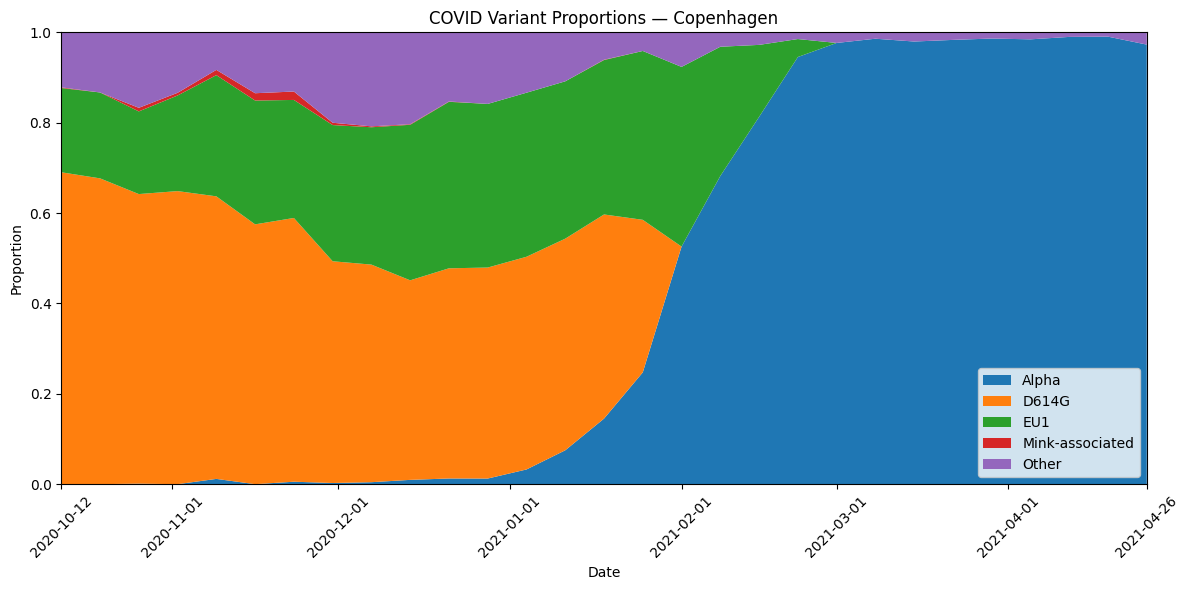

In [143]:
df_cph = df[df["region"] == "copenhagen"]

# Find first and last dates with data
# last_real = pd.Timestamp("2021-1-1")
last_real = df_cph.loc[df_cph["positive"] > 0, "date"].max()
first_real = df_cph.loc[df_cph["positive"] > 0, "date"].min()
# Compute proportions
counts = (
    df_cph.groupby(["date", "variant_group"])["positive"].sum().unstack(fill_value=0)
)

pivot = counts.div(counts.sum(axis=1), axis=0)

# Trim to data range
pivot = pivot.loc[first_real:last_real]

# Plot
plt.figure(figsize=(12, 6))
plt.stackplot(pivot.index, [pivot[col] for col in pivot.columns], labels=pivot.columns)

plt.legend(loc="lower right")
plt.title("COVID Variant Proportions — Copenhagen")
plt.xlabel("Date")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(first_real, last_real)

ax = plt.gca()

# Monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

# Force first and last dates to be included
ticks = ax.get_xticks()
ticks = np.unique(
    np.concatenate([[mdates.date2num(first_real)], ticks, [mdates.date2num(last_real)]])
)
ax.set_xticks(ticks)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()